# Non-Linear Economy Estimation (ANN)

Please note that this notebook uses a venv which points to a base python version of **3.13**, some functionality may be limited if using an older version of python.

## All Imports

In [1]:
%pip install pandas numpy torch --quiet

Note: you may need to restart the kernel to use updated packages.


In [2]:
%matplotlib widget

## Data From Source Package

In [3]:
%pip install -e .. --quiet # This is broken for soem reason still, figuring it out

Note: you may need to restart the kernel to use updated packages.


In [4]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent
SRC = REPO_ROOT / "src"

sys.path.insert(0, str(SRC))

import autonomous_fed as afed

In [5]:
solver = afed.EnvironmentSolver(fred_key="7ab121fb17773e187bb6508e83e411da", override_device="cpu")

# Data Check
print (solver.historical_data.head())
print (solver.historical_data.tail())

             pi         y     i
date                           
1987Q3  2.66122 -0.388640  6.84
1987Q4  2.91876  0.526730  6.92
1988Q1  3.06577  0.260731  6.66
1988Q2  3.35274  0.788853  7.16
1988Q3  3.80207  0.595530  7.98
             pi         y     i
date                           
2006Q2  3.35642  1.319357  4.91
2006Q3  3.13805  0.978513  5.25
2006Q4  2.66316  1.380249  5.25
2007Q1  2.91019  1.210046  5.26
2007Q2  2.72883  1.336951  5.25


## Model Architecture

### Single Hidden Layer NARX Model

For our economy transition equations we have: ${y_t=\hat{f}^y(y_{t-1},y_{t-2},\pi_t,\pi_{t-1},\pi_{t-2},i_t,i_{t-1},i_{t-2})+\epsilon_t^y}$ and ${\pi_t=\hat{f}^\pi(y_t,y_{t-1},y_{t-2},\pi_{t-1},\pi_{t-2},i_t,i_{t-1},i_{t-2})+\epsilon_t^\pi}$

In this scenario our predictor function, ${\hat{f}}$ is an ANN (Artificial Neural Network) but it can be swapped with other nonlinear functions such as a sigmoid function or wavelet network. For our ANN predictor we have ${\hat{f}^m=b_0^m+\sum_{j=1}^h v_j^mG(\omega_j^{m'}s_t^m+b_j^m), m\in\{y,\pi}\}$

The Components of the ANN are as follows:
- ${m}$: ${\{y,\pi}\}$
- ${s_t^m}$: Input state vectors at time t.
- ${w_j^m}$: Weight vector for the j-th hidden neuron.
- ${b_j^m}$: Bias term for the current neuron.
- ${G(\cdot)}$: Activation function (nonlinear transform).
- ${v_j^m}$: Weight from hidden neuron ${j}$ to the output layer
- ${b_0^m}$: Bias at the output layer
- ${h}$: Number of hidden neurons.

As seen above the Neural Network type is a NARX Model with a single hidden layer and the activation function is the hyperbolic tangent therefore we define ${G(\cdot)}$ as follows: ${G(x)=tanh(x)=\frac{e^x-e^{-x}}{e^x+e^{-x}}}$

As done in the reference paper the ANNs are intialized with Nguyen-Widrow Initialization. In addition to this we use the Levenberg-Marquardt Algorithm for our optimizer.

## Model Buildout

in the following cells we will replicate the Bundesbank's Neural Net as close as possible by rebuilding some of the MATLAB tools in python for use with PyTorch.

In [6]:
from typing import Iterable, Dict, Union, Tuple, Any, Optional
import random
from dataclasses import dataclass
import pandas as pd
import numpy as np
import torch
from torch import nn
from torch.nn.utils import parameters_to_vector, vector_to_parameters
from torch.utils.data import TensorDataset

Below we set the tensor dtype to float64 for pytorch because this model is being run locally on an ARM64 Macbook Pro. We can do training through the GPU by using MPS (Metal Performance Shaders) for our torch device but MPS does not support the float64 dtype only float32. As an effort to better replicate the MATLAB behavior from the reference paper we set dtype to float64 and bound our training to CPU for the torch device.

In [ ]:
DTYPE = torch.float64

torch.use_deterministic_algorithms(True)

# (Optional if you ever use CUDA)
# torch.backends.cuda.matmul.allow_tf32 = False
# torch.backends.cudnn.allow_tf32 = False

### MATLAB Functionality Replication

#### MapMinMax

In [8]:
from dataclasses import dataclass
from typing import Optional, Dict, Any

@dataclass
class MapMinMax:
    """
    MATLAB-like mapminmax for tabular tensors X shaped (N, P),
    where P = number of features (columns).

    Forward:
        Y = (X - xoffset) * gain + ymin
    Reverse:
        X = (Y - ymin) / gain + xoffset

    Stores MATLAB-style settings fields: xoffset, gain, ymin.
    """
    ymin: float = -1.0
    ymax: float =  1.0
    xoffset: Optional[torch.Tensor] = None  # (P,)
    gain: Optional[torch.Tensor] = None     # (P,)
    xmin: Optional[torch.Tensor] = None     # (P,)
    xmax: Optional[torch.Tensor] = None     # (P,)

    def fit(self, X: torch.Tensor) -> "MapMinMax":
        if X.ndim != 2:
            raise ValueError(f"Expected X with shape (N,P), got {tuple(X.shape)}")

        xmin = X.min(dim=0).values
        xmax = X.max(dim=0).values
        span = xmax - xmin

        # gain = (ymax-ymin)/(xmax-xmin), but handle constant columns safely
        # If span==0 -> map everything to midrange (ymin+ymax)/2
        gain = torch.empty_like(span)
        gain[span != 0] = (self.ymax - self.ymin) / span[span != 0]
        gain[span == 0] = 0.0  # constant feature

        self.xmin = xmin
        self.xmax = xmax
        self.xoffset = xmin
        self.gain = gain
        return self

    def transform(self, X: torch.Tensor) -> torch.Tensor:
        if self.xoffset is None or self.gain is None:
            raise RuntimeError("MapMinMax not fit().")

        Y = (X - self.xoffset) * self.gain + self.ymin

        # For constant columns (gain==0): set to midpoint of target range (MATLAB-compatible behavior)
        mid = 0.5 * (self.ymin + self.ymax)
        const = (self.gain == 0)
        if const.any():
            Y = Y.clone()
            Y[:, const] = mid
        return Y

    def inverse_transform(self, Y: torch.Tensor) -> torch.Tensor:
        if self.xoffset is None or self.gain is None or self.xmin is None:
            raise RuntimeError("MapMinMax not fit().")

        # Avoid divide-by-zero: for constant columns, return original constant xmin
        X = torch.empty_like(Y)
        const = (self.gain == 0)

        if (~const).any():
            X[:, ~const] = (Y[:, ~const] - self.ymin) / self.gain[~const] + self.xoffset[~const]
        if const.any():
            X[:, const] = self.xmin[const]  # constant original value
        return X

    def settings(self) -> Dict[str, Any]:
        """MATLAB-like settings struct (ps)"""
        if self.xoffset is None or self.gain is None:
            raise RuntimeError("MapMinMax not fit().")
        return {
            "name": "mapminmax",
            "ymin": float(self.ymin),
            "ymax": float(self.ymax),
            "xoffset": self.xoffset.detach().clone(),
            "gain": self.gain.detach().clone(),
        }

#### RemoveConstantCols (RemoveConstantRows)

In [9]:
from dataclasses import dataclass
from typing import Optional, Dict, Any

@dataclass
class RemoveConstantCols:
    """
    MATLAB-like removeconstantrows, adapted for tabular X shaped (N, P):
    removes constant *columns* (features) where max-min <= tol.

    Stores:
      - keep_mask: boolean mask of kept columns (P,)
      - const_values: original constant value for removed columns (K_removed,)
      - const_indices: indices of removed columns (K_removed,)
    """
    tol: float = 0.0
    keep_mask: Optional[torch.Tensor] = None        # (P,) bool
    const_indices: Optional[torch.Tensor] = None    # (K,) long
    const_values: Optional[torch.Tensor] = None     # (K,) same dtype as X

    def fit(self, X: torch.Tensor) -> "RemoveConstantCols":
        if X.ndim != 2:
            raise ValueError(f"Expected X with shape (N,P), got {tuple(X.shape)}")

        xmin = X.min(dim=0).values
        xmax = X.max(dim=0).values
        span = xmax - xmin

        keep = span > self.tol
        self.keep_mask = keep

        # record removed column indices + their (constant) value
        removed = (~keep).nonzero(as_tuple=False).reshape(-1)
        self.const_indices = removed.to(dtype=torch.long)

        if self.const_indices.numel() > 0:
            self.const_values = xmin[self.const_indices].detach().clone()
        else:
            self.const_values = torch.empty(0, dtype=X.dtype, device=X.device)

        return self

    def transform(self, X: torch.Tensor) -> torch.Tensor:
        if self.keep_mask is None:
            raise RuntimeError("RemoveConstantCols not fit().")
        if X.ndim != 2:
            raise ValueError(f"Expected X with shape (N,P), got {tuple(X.shape)}")
        return X[:, self.keep_mask]

    def inverse_transform(self, X_reduced: torch.Tensor) -> torch.Tensor:
        """
        Reconstruct full P columns by inserting removed constant columns back.
        """
        if self.keep_mask is None or self.const_indices is None or self.const_values is None:
            raise RuntimeError("RemoveConstantCols not fit().")
        if X_reduced.ndim != 2:
            raise ValueError(f"Expected X_reduced with shape (N,P_keep), got {tuple(X_reduced.shape)}")

        P = int(self.keep_mask.numel())
        N = int(X_reduced.shape[0])

        X_full = torch.empty((N, P), dtype=X_reduced.dtype, device=X_reduced.device)
        X_full[:, self.keep_mask] = X_reduced

        if self.const_indices.numel() > 0:
            X_full[:, self.const_indices] = self.const_values.to(device=X_reduced.device, dtype=X_reduced.dtype)

        return X_full

    def settings(self) -> Dict[str, Any]:
        """Small settings dict similar in spirit to MATLAB process settings."""
        if self.keep_mask is None:
            raise RuntimeError("RemoveConstantCols not fit().")
        return {
            "name": "removeconstantcols",
            "tol": float(self.tol),
            "keep_mask": self.keep_mask.detach().clone(),
            "const_indices": None if self.const_indices is None else self.const_indices.detach().clone(),
            "const_values": None if self.const_values is None else self.const_values.detach().clone(),
        }

#### Nguyen-Widrow Initialization

In our reference paper it is noted that the ANNs are initialized using the Nguyen-Widrow Method. This is done because we are using ${\tanh(x)}$ for our activation function which has saturation zones near -1 and 1. In order to properly replicate the paper and ensure neurons are placed in the high-information region of the activation function,we build a Nguyen-Widrow Initializer as follows:

$$
{w_i=\beta\times\frac{w_i^0}{||w_i^0||}, b_i~U[-\beta,\beta], \beta=0.7n_{out}^{1/n_{in}}}
$$


In [10]:
@torch.no_grad()
def nguyen_widrow_(layer: nn.Linear, input_min: float = -1.0, input_max: float = 1.0) -> None:
    """
    MATLAB-like initnw-style Nguyen-Widrow initialization.
    Assumes inputs have been scaled to [input_min, input_max] (default [-1,1]).
    """
    S, R = layer.weight.shape
    if R <= 0 or S <= 0:
        raise ValueError(f"Invalid layer shape: {(S, R)}")

    W = torch.empty_like(layer.weight).uniform_(-0.5, 0.5)
    norms = torch.norm(W, dim=1, keepdim=True).clamp_min(1e-12)
    W = W / norms

    beta = 0.7 * (S ** (1.0 / R))
    W = W * beta
    layer.weight.copy_(W)

    if layer.bias is not None:
        P = torch.empty((S, R), dtype=W.dtype, device=W.device).uniform_(input_min, input_max)
        b = -(W * P).sum(dim=1)
        layer.bias.copy_(b)

#### Single Hidden Layer Artificial Neural Network (NARX)

Below we mimic the refernce paper's Single-hidden-layer Artificial Neural Network with n-hidden nodes, ${\tanh(x)}$ activation function, and Nguyen-Widrow initialization.

In [11]:
from dataclasses import dataclass
from typing import Sequence, Optional, Tuple, Union

@dataclass(frozen=True)
class NarxSpec:
    """
    MATLAB-like NARX specification for narxnet.

    MATLAB expects delays as positive integers (typically 1:2).
    """
    input_delays: Tuple[int, ...] = (1, 2)
    feedback_delays: Tuple[int, ...] = (1, 2)

    def __post_init__(self) -> None:
        def _clean(ds: Sequence[int], name: str) -> Tuple[int, ...]:
            ds = tuple(int(d) for d in ds)
            if any(d <= 0 for d in ds):
                raise ValueError(f"{name} must be positive integers (MATLAB narxnet-style), got {ds}")
            return tuple(sorted(set(ds)))  # unique + sorted

        object.__setattr__(self, "input_delays", _clean(self.input_delays, "input_delays"))
        object.__setattr__(self, "feedback_delays", _clean(self.feedback_delays, "feedback_delays"))


class NARXNet(nn.Module):
    """
    MATLAB-like NARX network with tanh hidden activation and linear output.

    Open-loop (training): uses true y(t-d) feedback taps.
    Closed-loop (simulation): uses predicted yhat(t-d) feedback after seeding.

    Shapes:
      x_seq: (T, n_exog_in)
      y_seq: (T, n_out)
      returns yhat: (T - maxDelay, n_out)
    """
    def __init__(
        self,
        n_exog_in: int,
        hidden_sizes: Union[int, Sequence[int]],
        n_out: int,
        spec: Optional[NarxSpec] = None,
    ) -> None:
        super().__init__()
        self.spec = spec or NarxSpec()
        self.n_exog_in = int(n_exog_in)
        self.n_out = int(n_out)

        if isinstance(hidden_sizes, int):
            hs = (int(hidden_sizes),)
        else:
            hs = tuple(int(h) for h in hidden_sizes)
        if len(hs) == 0 or any(h <= 0 for h in hs):
            raise ValueError(f"hidden_sizes must be a positive int or a non-empty sequence, got {hidden_sizes}")

        n_in_total = self.n_exog_in * len(self.spec.input_delays) + self.n_out * len(self.spec.feedback_delays)

        # Hidden stack (MATLAB: tansig; here: tanh)
        self.hidden = nn.ModuleList()
        in_dim = n_in_total
        for h in hs:
            self.hidden.append(nn.Linear(in_dim, h))
            in_dim = h

        # Output (MATLAB: purelin)
        self.o = nn.Linear(in_dim, self.n_out)

        # Init: Nguyen-Widrow for each hidden layer (tanh), small uniform for linear output
        for layer in self.hidden:
            nguyen_widrow_(layer)

        bound = 0.03
        nn.init.uniform_(self.o.weight, -bound, bound)
        if self.o.bias is not None:
            nn.init.uniform_(self.o.bias, -bound, bound)

    @property
    def max_delay(self) -> int:
        md_in = max(self.spec.input_delays) if self.spec.input_delays else 0
        md_fb = max(self.spec.feedback_delays) if self.spec.feedback_delays else 0
        return max(md_in, md_fb)

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        # z is already tapped-delay features: (N, n_in_total)
        if z.dtype != self.o.weight.dtype:
            z = z.to(self.o.weight.dtype)

        x = z
        for layer in self.hidden:
            x = torch.tanh(layer(x))  # enforce tanh activation
        return self.o(x)  # linear output (MATLAB-like)

    def _tapped_block(self, seq: torch.Tensor, delays: Tuple[int, ...], t0: int) -> torch.Tensor:
        """
        Build tapped-delay block for times t=t0..T-1:
          block[t] = [seq(t-d1), seq(t-d2), ...] concatenated along feature dim.

        Returns shape: (T - t0, D * len(delays))
        """
        if seq.ndim != 2:
            raise ValueError(f"Expected seq with shape (T,D), got {tuple(seq.shape)}")
        if not delays:
            T = seq.shape[0]
            return torch.empty((T - t0, 0), dtype=seq.dtype, device=seq.device)

        T, _ = seq.shape
        if t0 < max(delays):
            raise ValueError(f"t0={t0} must be >= max(delays)={max(delays)}")

        cols = []
        for d in delays:
            cols.append(seq[(t0 - d) : (T - d), :])
        return torch.cat(cols, dim=1)

    def prepare_open_loop(self, x_seq: torch.Tensor, y_seq: torch.Tensor):
        """
        MATLAB preparets-like trimming/alignment.

        Returns:
          z      : (T - maxDelay, n_in_total)
          y_tgt  : (T - maxDelay, n_out)
          y_seed : (maxDelay, n_out)
        """
        if x_seq.ndim != 2 or y_seq.ndim != 2:
            raise ValueError(f"x_seq and y_seq must be 2D, got {x_seq.ndim}D and {y_seq.ndim}D")
        if x_seq.shape[0] != y_seq.shape[0]:
            raise ValueError(f"Time length mismatch: x_seq T={x_seq.shape[0]} vs y_seq T={y_seq.shape[0]}")
        if x_seq.shape[1] != self.n_exog_in:
            raise ValueError(f"x_seq has {x_seq.shape[1]} features but expected {self.n_exog_in}")
        if y_seq.shape[1] != self.n_out:
            raise ValueError(f"y_seq has {y_seq.shape[1]} outputs but expected {self.n_out}")

        t0 = self.max_delay
        if x_seq.shape[0] <= t0:
            raise ValueError(f"Sequence too short: T={x_seq.shape[0]} <= maxDelay={t0}")

        Xd = self._tapped_block(x_seq, self.spec.input_delays, t0)
        Yd = self._tapped_block(y_seq, self.spec.feedback_delays, t0)
        z = torch.cat([Xd, Yd], dim=1)

        y_tgt = y_seq[t0:, :]
        y_seed = y_seq[:t0, :]
        return z, y_tgt, y_seed

    def forward_open_loop(self, x_seq: torch.Tensor, y_seq: torch.Tensor) -> torch.Tensor:
        """Open-loop (teacher forcing)."""
        z, _, _ = self.prepare_open_loop(x_seq, y_seq)
        return self.forward(z)

    @torch.no_grad()
    def forward_closed_loop(self, x_seq: torch.Tensor, y_seed: torch.Tensor) -> torch.Tensor:
        """
        Closed-loop simulation (MATLAB closeloop-like behavior):
        feedback taps come from the model predictions after seeding.
        """
        if x_seq.ndim != 2:
            raise ValueError(f"Expected x_seq with shape (T, n_exog_in), got {tuple(x_seq.shape)}")

        T = int(x_seq.shape[0])
        t0 = self.max_delay
        if y_seed.shape != (t0, self.n_out):
            raise ValueError(f"y_seed must have shape {(t0, self.n_out)} but got {tuple(y_seed.shape)}")

        device = self.o.weight.device
        dtype = self.o.weight.dtype
        x_seq = x_seq.to(device=device, dtype=dtype)
        y_seed = y_seed.to(device=device, dtype=dtype)

        # exogenous taps are always taken from the provided x_seq (like MATLAB, where future inputs can be known)
        Xd = self._tapped_block(x_seq, self.spec.input_delays, t0)

        y_hist = [y_seed[t].clone() for t in range(t0)]
        preds = []

        fb_delays = self.spec.feedback_delays
        for k in range(T - t0):
            t = t0 + k

            if fb_delays:
                fb = torch.cat([y_hist[t - d] for d in fb_delays], dim=0).view(1, -1)
            else:
                fb = torch.empty((1, 0), dtype=dtype, device=device)

            zt = torch.cat([Xd[k : k + 1, :], fb], dim=1)
            y_t = self.forward(zt)  # (1, n_out)

            y_hist.append(y_t.squeeze(0))
            preds.append(y_t.squeeze(0))

        return torch.stack(preds, dim=0)

#### Levenberg-Marquardt Optimizer

In the Bundesbank paper, in addition to the Nguyen Widrow Initializer, the networks are trained using the Levenberg-Marquardt Algorithm, thus we build an optimizer to mimic this behavior.

In [12]:
class LevenbergMarquardt(torch.optim.Optimizer):
    """
    MATLAB-trainlm-like Levenberg-Marquardt optimizer (full-batch).
    - Uses accept/reject based on SSE decrease
    - On reject: restores params and increases μ, retries
    - On accept: decreases μ

    NOTE: Builds full Jacobian explicitly (slow for large M,P).
    """

    def __init__(
        self,
        params,
        mu: float = 1e-3,
        mu_dec: float = 0.1,
        mu_inc: float = 10.0,
        mu_max: float = 1e10,
        weight_decay: float = 0.0,
        max_trials: int = 50,
    ) -> None:
        if mu <= 0:
            raise ValueError("mu must be > 0")
        defaults = dict(
            mu=float(mu),
            mu_dec=float(mu_dec),
            mu_inc=float(mu_inc),
            mu_max=float(mu_max),
            weight_decay=float(weight_decay),
            max_trials=int(max_trials),
        )
        super().__init__(params, defaults)

    def _params_vector(self):
        ps = []
        for group in self.param_groups:
            for p in group["params"]:
                if p.requires_grad:
                    ps.append(p)
        return ps, parameters_to_vector(ps)

    @torch.no_grad()
    def _set_theta(self, params, theta: torch.Tensor) -> None:
        vector_to_parameters(theta, params)

    def _compute_r_and_J(self, closure) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        """
        Returns:
          rr: residuals with grad graph (M,)
          r0: detached residuals (M,)
          J : (M,P)
        """
        params, theta0 = self._params_vector()
        P = int(theta0.numel())

        with torch.enable_grad():
            rr = closure().reshape(-1)  # graph
            M = int(rr.numel())
            J = torch.zeros((M, P), dtype=theta0.dtype, device=theta0.device)

            for i in range(M):
                for p in params:
                    if p.grad is not None:
                        p.grad = None
                grad_i = torch.autograd.grad(rr[i], params, retain_graph=True, allow_unused=False)
                J[i] = parameters_to_vector(grad_i)

        r0 = rr.detach()
        return rr, r0, J

    @torch.no_grad()
    def step(self, closure) -> Dict[str, float | bool | int]:
        """
        closure() must return a 1D residual vector r = (pred - target).reshape(-1)
        """
        group = self.param_groups[0]
        mu = float(group["mu"])
        mu_dec = float(group["mu_dec"])
        mu_inc = float(group["mu_inc"])
        mu_max = float(group["mu_max"])
        wd = float(group["weight_decay"])
        max_trials = int(group["max_trials"])

        params, theta0 = self._params_vector()
        P = int(theta0.numel())

        # Compute r and J at current theta
        _, r0, J = self._compute_r_and_J(closure)
        r0 = r0.reshape(-1)
        M = int(r0.numel())

        sse0 = float((r0 @ r0).item())
        g = J.T @ r0  # (P,)
        g_norm = float(torch.linalg.norm(g).item())

        JTJ = J.T @ J
        if wd != 0.0:
            JTJ = JTJ + wd * torch.eye(P, device=JTJ.device, dtype=JTJ.dtype)

        accepted = False
        trials = 0
        sse1 = sse0

        # MATLAB-like: keep increasing mu until step is accepted or mu_max hit
        while trials < max_trials:
            trials += 1
            if mu > mu_max:
                break

            A = JTJ + mu * torch.eye(P, device=JTJ.device, dtype=JTJ.dtype)
            rhs = -g

            try:
                dtheta = torch.linalg.solve(A, rhs)
            except RuntimeError:
                dtheta = torch.linalg.lstsq(A, rhs.unsqueeze(1)).solution.squeeze(1)

            theta1 = theta0 + dtheta
            self._set_theta(params, theta1)

            # evaluate new SSE (no grad)
            r1 = closure().detach().reshape(-1)
            sse1 = float((r1 @ r1).item())

            if sse1 < sse0:  # accept
                accepted = True
                mu = max(1e-30, mu * mu_dec)
                break

            # reject -> restore and increase mu
            self._set_theta(params, theta0)
            mu = mu * mu_inc

        group["mu"] = mu

        return {
            "accepted": accepted,
            "mu": mu,
            "trials": trials,
            "M": M,
            "old_sse": sse0,
            "new_sse": sse1,
            "g_norm": g_norm,
            "mu_max_hit": (mu > mu_max),
        }

#### TrainLM

In [13]:
def trainlm(
    model: nn.Module,
    train_ds: TensorDataset,
    val_ds: TensorDataset,
    *,
    epochs: int = 200,
    goal: float = 0.0,
    min_grad: float = 1e-10,
    mu: float = 1e-3,
    mu_dec: float = 0.1,
    mu_inc: float = 10.0,
    mu_max: float = 1e10,
    max_fail: int = 6,
    show: int = 10,
) -> tuple[float, nn.Module]:
    """
    MATLAB-like trainlm driver:
    - full-batch LM steps
    - validation early stopping via max_fail
    - stops on goal, min_grad, mu_max
    """
    Xtr, ytr = train_ds.tensors
    Xva, yva = val_ds.tensors

    model = model.to(dtype=DTYPE, device="cpu")
    Xtr, ytr = Xtr.to(DTYPE), ytr.to(DTYPE)
    Xva, yva = Xva.to(DTYPE), yva.to(DTYPE)

    opt = LevenbergMarquardt(
        model.parameters(),
        mu=mu,
        mu_dec=mu_dec,
        mu_inc=mu_inc,
        mu_max=mu_max,
    )

    best = {"val_mse": float("inf"), "state": None, "epoch": -1}
    fail = 0

    def closure_train():
        # return residual vector (M,)
        pred = model(Xtr)
        return (pred - ytr).reshape(-1)

    def mse_from_sse(sse: float, M: int) -> float:
        return float(sse) / float(M)

    for ep in range(int(epochs)):
        model.train()
        info = opt.step(closure_train)

        train_mse = mse_from_sse(info["new_sse"], info["M"])

        model.eval()
        with torch.no_grad():
            rva = (model(Xva) - yva).reshape(-1)
            val_mse = float((rva @ rva).item()) / float(rva.numel())

        # stopping criteria
        if train_mse <= goal:
            if (ep + 1) % show == 0 or ep == 0:
                print(f"Epoch {ep+1:03d}: goal reached (train_mse={train_mse:.6e})")
            break
        if info["g_norm"] <= min_grad:
            if (ep + 1) % show == 0 or ep == 0:
                print(f"Epoch {ep+1:03d}: min_grad reached (||g||={info['g_norm']:.2e})")
            break
        if info["mu_max_hit"]:
            print(f"Epoch {ep+1:03d}: mu_max hit (mu={info['mu']:.2e})")
            break

        # validation early stopping (MATLAB max_fail behavior)
        if val_mse < best["val_mse"] - 1e-12:
            best["val_mse"] = val_mse
            best["state"] = {k: v.detach().clone() for k, v in model.state_dict().items()}
            best["epoch"] = ep
            fail = 0
        else:
            fail += 1
            if fail >= max_fail:
                break

        if (ep + 1) % show == 0 or ep == 0:
            print(
                f"Epoch {ep+1:03d}: "
                f"train_mse={train_mse:.6e} val_mse={val_mse:.6e} "
                f"mu={info['mu']:.2e} accepted={info['accepted']} trials={info['trials']}"
            )

    if best["state"] is not None:
        model.load_state_dict(best["state"])

    return float(best["val_mse"]), model

### Training, Searching, and Optimization Replication

In [14]:
# -------------------------
# NARX (MATLAB-style) data prep + search
# -------------------------

def _infer_exog_cols(target_col: str) -> Tuple[str, ...]:
    # Exogenous inputs used by the NARX.
    # Adjust if the paper specifies something else.
    if target_col == "y":
        return ("pi", "i")
    if target_col == "pi":
        return ("y", "i")
    raise ValueError("target_col must be 'y' or 'pi'.")


def make_narx_state_matrix(
    df: pd.DataFrame,
    *,
    target_col: str,
    spec: NarxSpec,
    exog_cols: Optional[Tuple[str, ...]] = None,
) -> Tuple[torch.Tensor, torch.Tensor, pd.Index, list[str]]:
    """
    Build an *interpretable* state matrix in ORIGINAL units:
      S_raw rows correspond to time t = maxDelay..end
      columns are [exog(t-d) for d in input_delays] + [y(t-d) for d in feedback_delays]
    This is useful for plotting / PDP while still being consistent with NARXNet taps.
    """
    data = df.copy().sort_index()

    exog_cols = tuple(exog_cols) if exog_cols is not None else _infer_exog_cols(target_col)

    needed = set(exog_cols) | {target_col}
    missing = needed - set(data.columns)
    if missing:
        raise ValueError(f"DataFrame missing required columns: {missing}")

    # create lagged columns
    for x in exog_cols:
        for d in spec.input_delays:
            data[f"{x}_lag{d}"] = data[x].shift(d)
    for d in spec.feedback_delays:
        data[f"{target_col}_lag{d}"] = data[target_col].shift(d)

    feature_cols: list[str] = []
    for d in spec.input_delays:
        for x in exog_cols:
            feature_cols.append(f"{x}_lag{d}")
    for d in spec.feedback_delays:
        feature_cols.append(f"{target_col}_lag{d}")

    # target at time t
    y_series = data[target_col]

    mask = data[feature_cols].notna().all(axis=1) & y_series.notna()
    X_np = data.loc[mask, feature_cols].values.astype(np.float64)
    y_np = y_series.loc[mask].values.astype(np.float64).reshape(-1, 1)
    idx  = data.index[mask]

    S_raw = torch.as_tensor(X_np, dtype=DTYPE)
    y_raw = torch.as_tensor(y_np, dtype=DTYPE)
    return S_raw, y_raw, idx, feature_cols


class NarxStateTransformer:
    """
    Adapter so existing code that expects x_scaler.transform(X_raw)
    can still work, but now X_raw is a NARX *state* matrix in original units.
    """
    def __init__(self, *, spec: NarxSpec, exog_cols: Tuple[str, ...], target_col: str, x_scaler: MapMinMax, y_scaler: MapMinMax):
        self.spec = spec
        self.exog_cols = exog_cols
        self.target_col = target_col
        self.x_scaler = x_scaler
        self.y_scaler = y_scaler

    def transform(self, S_raw: torch.Tensor) -> torch.Tensor:
        """
        Convert state matrix (original units) -> tapped-delay z (scaled) in the SAME ORDER as:
          [x(t-d) blocks for d in input_delays] + [y(t-d) blocks for d in feedback_delays]
        """
        S_raw = S_raw.to(dtype=DTYPE)

        n_exog = len(self.exog_cols)
        # columns are ordered as we built them:
        #  for d in input_delays: for x in exog_cols: x_lag{d}
        # then feedback lags: target_lag{d}

        # exog part
        Xd_scaled_blocks = []
        offset = 0
        for _d in self.spec.input_delays:
            Xd_raw = S_raw[:, offset : offset + n_exog]          # (N, n_exog)
            Xd_scaled_blocks.append(self.x_scaler.transform(Xd_raw))
            offset += n_exog

        # feedback part (each lag is shape (N,1))
        Yd_scaled_blocks = []
        for _d in self.spec.feedback_delays:
            yd_raw = S_raw[:, offset : offset + 1]               # (N, 1)
            Yd_scaled_blocks.append(self.y_scaler.transform(yd_raw))
            offset += 1

        return torch.cat(Xd_scaled_blocks + Yd_scaled_blocks, dim=1)


def make_narx_open_loop_fixed_split(
    df: pd.DataFrame,
    *,
    target_col: str,
    spec: Optional[NarxSpec] = None,
    exog_cols: Optional[Tuple[str, ...]] = None,
    holdout_frac: float = 0.15,
) -> Tuple[TensorDataset, TensorDataset, Dict[str, Any]]:
    """
    Paper-style fixed split for NARX in open-loop (teacher forcing):
      - Build state matrix S_raw (original units)
      - Split time-ordered into train/val
      - Fit mapminmax scalers on TRAIN ONLY:
          * x_scaler on exogenous variables (not on full lag-expanded matrix)
          * y_scaler on target values
      - Convert S_raw -> z_scaled via NarxStateTransformer
      - Return TensorDataset(z_scaled, y_scaled)
    """
    spec = spec or NarxSpec()
    exog_cols = tuple(exog_cols) if exog_cols is not None else _infer_exog_cols(target_col)

    # full aligned state matrix (t >= maxDelay)
    S_raw, y_raw, idx_tgt, state_feature_cols = make_narx_state_matrix(
        df, target_col=target_col, spec=spec, exog_cols=exog_cols
    )

    N = int(S_raw.shape[0])
    n_tr = int(np.floor((1.0 - holdout_frac) * N))
    if n_tr <= 0 or n_tr >= N:
        raise ValueError(f"Bad split: N={N}, holdout_frac={holdout_frac}")

    # Fit scalers on TRAIN ONLY, but in the MATLAB spirit:
    # - x_scaler is fit on the *exogenous variables* (original x(t) samples), not on lag-expanded columns.
    # Here we approximate that by fitting on the exogenous-lag1 block from TRAIN (same variable-wise scale).
    n_exog = len(exog_cols)
    x_lag1_block = S_raw[:n_tr, 0:n_exog]  # corresponds to input_delays[0] block by construction
    x_scaler = MapMinMax().fit(x_lag1_block)

    y_scaler = MapMinMax().fit(y_raw[:n_tr])

    xform = NarxStateTransformer(spec=spec, exog_cols=exog_cols, target_col=target_col, x_scaler=x_scaler, y_scaler=y_scaler)

    z_tr = xform.transform(S_raw[:n_tr])
    z_va = xform.transform(S_raw[n_tr:])

    y_tr = y_scaler.transform(y_raw[:n_tr])
    y_va = y_scaler.transform(y_raw[n_tr:])

    train_ds = TensorDataset(z_tr, y_tr)
    val_ds   = TensorDataset(z_va, y_va)

    meta = {
        "spec": spec,
        "target_col": target_col,
        "exog_cols": exog_cols,
        "n_tr": n_tr,
        "idx_tgt": idx_tgt,
        "y_tgt_raw": y_raw,
        "state_feature_cols": state_feature_cols,
        "state_full_raw": S_raw,
        "x_scaler": x_scaler,
        "y_scaler": y_scaler,
        "x_transformer": xform,   # for PDP/surfaces (drop-in for x_scaler in pd_surface_constrained)
    }
    return train_ds, val_ds, meta


def search_hidden_units_LM(
    df: pd.DataFrame,
    target_col: str,
    hidden_grid: range = range(1, 11),
    seeds: int = 30,
    holdout_frac: float = 0.15,
    spec: Optional[NarxSpec] = None,
    exog_cols: Optional[Tuple[str, ...]] = None,
) -> Dict[str, Union[float, int, nn.Module, Dict[str, Any]]]:
    """
    Paper replication using NARXNet + trainlm:
      - 85/15 split (time-ordered)
      - h in 1..10
      - 30 random initializations per h (same split)
      - choose h with lowest mean validation MSE across 30 runs (in original units)
    """
    spec = spec or NarxSpec()

    overall: Dict[str, Any] = {"metric": float("inf")}

    for h in hidden_grid:
        train_ds, val_ds, meta = make_narx_open_loop_fixed_split(
            df,
            target_col=target_col,
            spec=spec,
            exog_cols=exog_cols,
            holdout_frac=holdout_frac,
        )

        mses = []
        runs = []

        n_exog = len(meta["exog_cols"])
        for s in range(seeds):
            seed = 10_000 + 97 * int(h) + int(s)
            torch.manual_seed(seed)
            np.random.seed(seed)
            random.seed(seed)

            model = NARXNet(
                n_exog_in=n_exog,
                hidden_sizes=int(h),   # single hidden layer
                n_out=1,
                spec=spec,
            ).to(dtype=DTYPE)

            # Train on SCALED (z -> y)
            _, fitted = trainlm(model, train_ds, val_ds)

            # Score on validation in ORIGINAL units
            with torch.no_grad():
                z_va_s, _ = val_ds.tensors
                yhat_s = fitted(z_va_s)
                yhat = meta["y_scaler"].inverse_transform(yhat_s)
                ytrue = meta["y_tgt_raw"][meta["n_tr"]:, :]
                val_mse_orig = float(((yhat - ytrue) ** 2).mean().item())

            mses.append(val_mse_orig)
            runs.append((val_mse_orig, fitted))

        mean_mse = float(np.mean(mses))
        best_run = min(runs, key=lambda t: t[0])

        print(f"h={h:2d}  mean(val MSE)={mean_mse:.6f}  best(val MSE)={best_run[0]:.6f}")

        if mean_mse < overall["metric"]:
            overall = {
                "metric": mean_mse,
                "h": int(h),
                "model": best_run[1],
                "meta": meta,
                "per_seed_val_mse": mses,
            }

    print("\n=== Overall Best (by mean val MSE over 30 runs) ===")
    print(f"h = {overall['h']},  mean val MSE = {overall['metric']:.6f}")
    return overall


@torch.no_grad()
def predict_narx_from_state(
    model: nn.Module,
    S_raw: torch.Tensor,
    *,
    x_transformer: NarxStateTransformer,
    y_scaler: MapMinMax,
    device: str = "cpu",
) -> np.ndarray:
    """
    Predict y(t) for each row in S_raw (which is already aligned to t>=maxDelay),
    returning predictions in ORIGINAL units.
    """
    model = model.to(device=device, dtype=DTYPE)
    S_raw = S_raw.to(device=device, dtype=DTYPE)

    z_s = x_transformer.transform(S_raw)
    yhat_s = model(z_s)
    yhat = y_scaler.inverse_transform(yhat_s)
    return yhat.detach().cpu().numpy().reshape(-1)

### Scale, Train, Search, and Invert 

In [15]:
best_y  = search_hidden_units_LM(solver.historical_data, target_col="y")
best_pi = search_hidden_units_LM(solver.historical_data, target_col="pi")

Epoch 001: train_mse=5.359144e-02 val_mse=1.168241e-01 mu=1.00e-02 accepted=True trials=3
Epoch 001: train_mse=1.042098e-01 val_mse=9.002347e-02 mu=1.00e-04 accepted=True trials=1
Epoch 010: train_mse=3.009302e-02 val_mse=1.714495e-02 mu=1.00e-05 accepted=True trials=1
Epoch 001: train_mse=7.244753e-02 val_mse=2.593843e-01 mu=1.00e-01 accepted=True trials=4
Epoch 001: train_mse=1.754559e-01 val_mse=1.259380e-01 mu=1.00e-04 accepted=True trials=1
Epoch 010: train_mse=3.009462e-02 val_mse=1.726629e-02 mu=1.00e-05 accepted=True trials=1
Epoch 001: train_mse=2.810638e-01 val_mse=1.926628e-01 mu=1.00e+00 accepted=True trials=5
Epoch 001: train_mse=2.476312e-01 val_mse=2.131038e-01 mu=1.00e-03 accepted=True trials=2
Epoch 010: train_mse=3.009288e-02 val_mse=1.706113e-02 mu=1.00e-10 accepted=True trials=1
Epoch 001: train_mse=2.033144e-01 val_mse=1.517899e-01 mu=1.00e-01 accepted=True trials=4
Epoch 010: train_mse=3.009288e-02 val_mse=1.705399e-02 mu=1.00e-07 accepted=True trials=1
Epoch 001:

In [16]:
y_meta = best_y["meta"]
pi_meta = best_pi["meta"]

print(f"Best y model has {best_y['h']} hidden units with val MSE = {best_y['metric']:.6f}")
print(f"Best pi model has {best_pi['h']} hidden units with val MSE = {best_pi['metric']:.6f}")

Best y model has 1 hidden units with val MSE = 0.127989
Best pi model has 3 hidden units with val MSE = 0.067031


In [17]:
y_meta  = best_y["meta"]
pi_meta = best_pi["meta"]

device = "cpu"

# validation slices
y_S_val  = y_meta["state_full_raw"][y_meta["n_tr"]:, :]
pi_S_val = pi_meta["state_full_raw"][pi_meta["n_tr"]:, :]

yhat_val = predict_narx_from_state(
    best_y["model"],
    y_S_val,
    x_transformer=y_meta["x_transformer"],
    y_scaler=y_meta["y_scaler"],
    device=device,
)
pihat_val = predict_narx_from_state(
    best_pi["model"],
    pi_S_val,
    x_transformer=pi_meta["x_transformer"],
    y_scaler=pi_meta["y_scaler"],
    device=device,
)

print("Validation Predictions for y:")
print(yhat_val)
print("Validation Predictions for pi:")
print(pihat_val)

Validation Predictions for y:
[-0.14111696  0.18503363  0.53783328  0.91951599  0.94920834  1.03270253
  1.04457306  1.41973883  1.48421385  1.164818    1.1735396   1.23885988]
Validation Predictions for pi:
[2.82593552 2.92748693 3.15689872 3.24412989 3.06424087 3.39239504
 3.34412569 3.25756949 3.3035505  3.0788643  2.66941622 2.93782354]


#### Full Data Matrix

We create the following function to capture the entire dataset for running the ANN with the optimal number of hidden units now that the search ahs been performed.

### Figure 4 Output Gap Fit: Squared Errors (Replication)

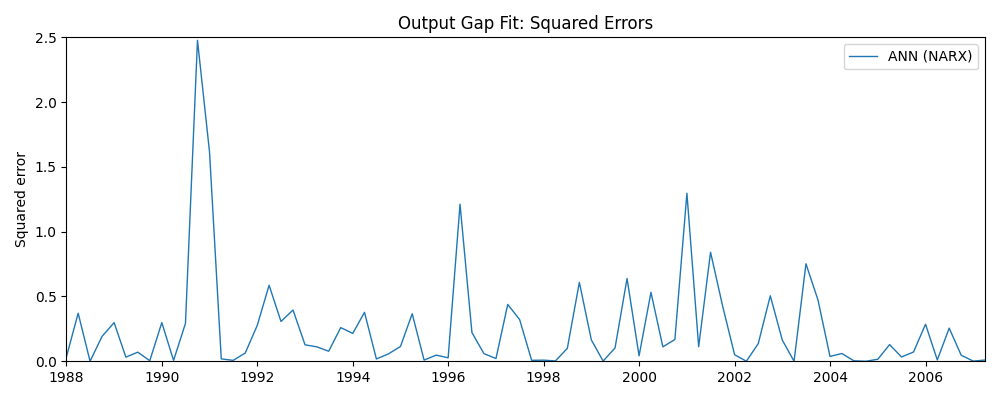

In [18]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

# === Full-sample (aligned) series for y ===
idx_full_y = y_meta["idx_tgt"]
if isinstance(idx_full_y, pd.PeriodIndex):
    idx_plot = idx_full_y.to_timestamp()
else:
    idx_plot = pd.to_datetime(idx_full_y)

y_full_true = y_meta["y_tgt_raw"].detach().cpu().numpy().reshape(-1)

y_full_hat_ann = predict_narx_from_state(
    best_y["model"],
    y_meta["state_full_raw"],
    x_transformer=y_meta["x_transformer"],
    y_scaler=y_meta["y_scaler"],
    device="cpu",
)

sq_err_ann = (y_full_true - y_full_hat_ann) ** 2

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(idx_plot, sq_err_ann, label="ANN (NARX)", linewidth=1)
ax.set_title("Output Gap Fit: Squared Errors")
ax.set_ylabel("Squared error")
ax.set_xlabel("")
ax.set_ylim(0, 2.5)

ax.set_xlim(idx_plot[0], idx_plot[-1])
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

### Figure 5 Inflation Fit: Squared Errors (Replication)

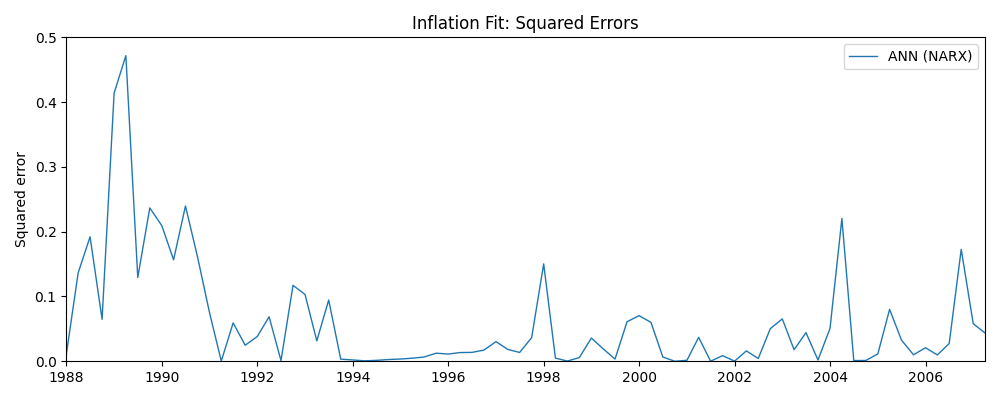

In [19]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

idx_full_pi = pi_meta["idx_tgt"]
if isinstance(idx_full_pi, pd.PeriodIndex):
    idx_plot_pi = idx_full_pi.to_timestamp()
else:
    idx_plot_pi = pd.to_datetime(idx_full_pi)

pi_full_true = pi_meta["y_tgt_raw"].detach().cpu().numpy().reshape(-1)

pi_full_hat_ann = predict_narx_from_state(
    best_pi["model"],
    pi_meta["state_full_raw"],
    x_transformer=pi_meta["x_transformer"],
    y_scaler=pi_meta["y_scaler"],
    device="cpu",
)

sq_err_ann_pi = (pi_full_true - pi_full_hat_ann) ** 2

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(idx_plot_pi, sq_err_ann_pi, label="ANN (NARX)", linewidth=1)
ax.set_title("Inflation Fit: Squared Errors")
ax.set_ylabel("Squared error")
ax.set_xlabel("")
ax.set_ylim(0, 0.5)

ax.set_xlim(idx_plot_pi[0], idx_plot_pi[-1])
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

### Table 3 Economy Fit: Mean Squared Errors

In [20]:
from IPython.display import Markdown, display

svar_y_msq = solver.squared_errors_data["se_y_svar"].mean()
svar_pi_msq = solver.squared_errors_data["se_pi_svar"].mean()
ann_y_msq = np.mean(sq_err_ann)
ann_pi_msq = np.mean(sq_err_ann_pi)

table_three_str = fr"""
| Representation | MSE Output Gap   | MSE Inflation     | MSE Total                        |
|----------------|------------------|-------------------|----------------------------------|
| SVAR           | {svar_y_msq:.3f} | {svar_pi_msq:.3f} | {(svar_pi_msq+svar_y_msq)/2:.3f} |
| ANN            | {ann_y_msq:.3f}  | {ann_pi_msq:.3f}  | {(ann_y_msq+ann_pi_msq)/2:.3f}   |
"""

display(Markdown(table_three_str))


| Representation | MSE Output Gap   | MSE Inflation     | MSE Total                        |
|----------------|------------------|-------------------|----------------------------------|
| SVAR           | 0.211 | 0.032 | 0.122 |
| ANN            | 0.252  | 0.059  | 0.156   |


### PDP Functions

In [21]:
import numpy as np
import torch
import matplotlib.pyplot as plt

@torch.no_grad()
def pd_surface_constrained(
    model,
    X_raw: torch.Tensor,        # (N,p) unscaled, original units
    x_scaler,
    y_scaler,
    feature_cols: list[str],
    grid_x_feat: str,
    grid_y_feat: str,
    grid_x_n: int = 25,
    grid_y_n: int = 25,
    q_low: float = 0.02,
    q_high: float = 0.98,
    sample: int | None = 2000,
    tie_groups: list[tuple[str, ...]] | None = None,
    device: str = "cpu",
):
    """
    Partial dependence surface with equality constraints.
    - grid_x_feat and grid_y_feat are the two "axis" variables.
    - tie_groups enforces equalities:
        * If a group contains a grid feature -> all in that group set to the grid value.
        * If a group contains no grid feature -> set all members equal ROW-WISE to the first member.
          (This matches "assume a=b" while still marginalizing over the distribution of 'a'.)
    Returns: gx, gy, Z (Z shape: (len(gy), len(gx)))
    """
    tie_groups = tie_groups or []

    # Subsample for speed (still valid: PDP is an average over rows)
    X0 = X_raw
    N = X0.shape[0]
    if sample is not None and sample < N:
        idx = torch.randperm(N)[:sample]
        X0 = X0[idx]

    def col_idx(name: str) -> int:
        if name not in feature_cols:
            raise ValueError(f"{name} not in feature_cols: {feature_cols}")
        return feature_cols.index(name)

    ix = col_idx(grid_x_feat)
    iy = col_idx(grid_y_feat)

    x_vals = X0[:, ix].detach().cpu().numpy()
    y_vals = X0[:, iy].detach().cpu().numpy()
    lo_x, hi_x = np.quantile(x_vals, [q_low, q_high])
    lo_y, hi_y = np.quantile(y_vals, [q_low, q_high])

    gx = np.linspace(lo_x, hi_x, grid_x_n)
    gy = np.linspace(lo_y, hi_y, grid_y_n)

    model = model.to(device=device, dtype=X0.dtype)
    X0 = X0.to(device=device, dtype=X0.dtype)

    # Precompute tie indices
    tie_idx_groups = []
    for g in tie_groups:
        tie_idx_groups.append([col_idx(n) for n in g])

    Z = np.zeros((grid_y_n, grid_x_n), dtype=np.float64)

    for j, yv in enumerate(gy):
        for i, xv in enumerate(gx):
            Xg = X0.clone()

            # Set the grid axes
            Xg[:, ix] = float(xv)
            Xg[:, iy] = float(yv)

            # Enforce tie constraints
            for g_idx in tie_idx_groups:
                # If group includes an axis feature, tie all to that axis value
                if ix in g_idx:
                    for k in g_idx:
                        Xg[:, k] = float(xv)
                elif iy in g_idx:
                    for k in g_idx:
                        Xg[:, k] = float(yv)
                else:
                    # Row-wise tie to the first column in the group
                    base_col = g_idx[0]
                    for k in g_idx[1:]:
                        Xg[:, k] = Xg[:, base_col]

            # Predict, then average over rows (marginalization)
            Xs = x_scaler.transform(Xg)
            yhat_s = model(Xs)
            yhat = y_scaler.inverse_transform(yhat_s)
            Z[j, i] = float(yhat.mean().detach().cpu().item())

    return gx, gy, Z


def plot_surface(gx, gy, Z, xlabel, ylabel, zlabel, title):
    X, Y = np.meshgrid(gx, gy)
    fig = plt.figure(figsize=(8, 5.5))
    ax = fig.add_subplot(111, projection="3d")
    ax.plot_surface(X, Y, Z, cmap="viridis", linewidth=0.2, antialiased=True)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_zlabel(zlabel)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

#### Figure 6: Partial Dependence Surface Plot - ANN Economy, Inflation

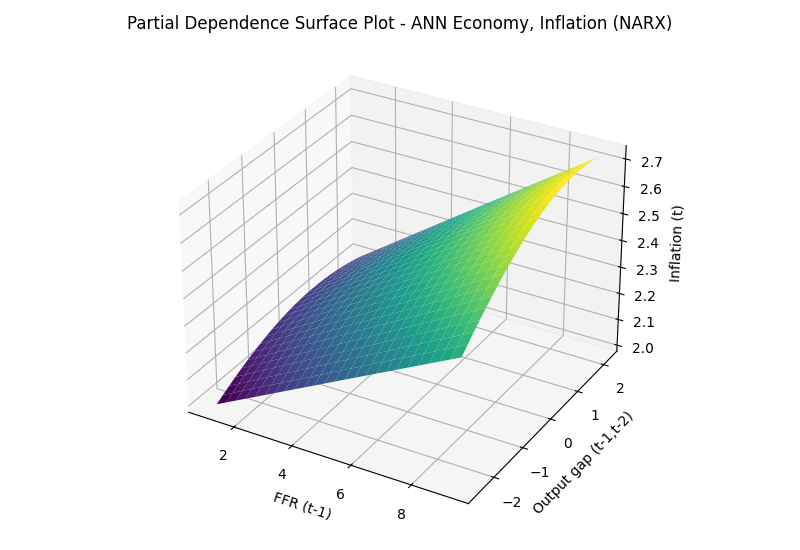

In [22]:
# Inflation surface: pi_hat = f(y, y_lag1, y_lag2, pi_lag1, pi_lag2, i_lag1)
# Match paper constraints:
#   y = y(t-1) = y(t-2)
#   pi(t-1) = pi(t-2)
gx, gy, Z = pd_surface_constrained(
    model=best_pi["model"],
    X_raw=pi_meta["state_full_raw"],
    x_scaler=pi_meta["x_transformer"],   # <-- transformer (state -> z_scaled)
    y_scaler=pi_meta["y_scaler"],
    feature_cols=pi_meta["state_feature_cols"],
    grid_x_feat="i_lag1",
    grid_y_feat="y_lag1",
    grid_x_n=25,
    grid_y_n=25,
    sample=2500,
    tie_groups=[
        ("y_lag1", "y_lag2"),
        ("pi_lag1", "pi_lag2"),
    ],
    device="cpu",
)

plot_surface(
    gx, gy, Z,
    xlabel="FFR (t-1)",
    ylabel="Output gap (t-1,t-2)",
    zlabel="Inflation (t)",
    title="Partial Dependence Surface Plot - ANN Economy, Inflation (NARX)",
)

#### Figure 7: Partial Dependence Surface Plot - ANN Economy, Output Gap

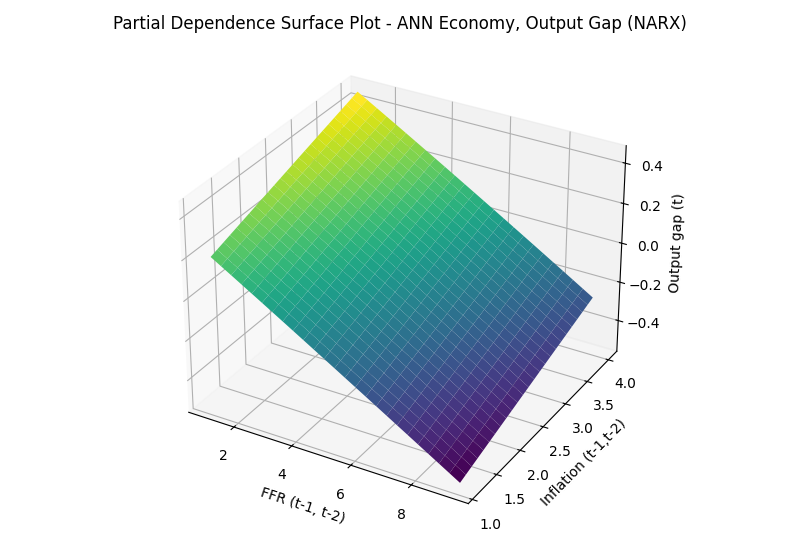

In [23]:
# Output gap surface: y_hat = f(y_lag1, pi_lag1, i_lag1, i_lag2)
# Match paper constraint: i(t-1) = i(t-2)
gx, gy, Z = pd_surface_constrained(
    model=best_y["model"],
    X_raw=y_meta["state_full_raw"],
    x_scaler=y_meta["x_transformer"],
    y_scaler=y_meta["y_scaler"],
    feature_cols=y_meta["state_feature_cols"],
    grid_x_feat="i_lag1",
    grid_y_feat="pi_lag1",
    grid_x_n=25,
    grid_y_n=25,
    sample=2500,
    tie_groups=[("i_lag1", "i_lag2")],
    device="cpu",
)

plot_surface(
    gx, gy, Z,
    xlabel="FFR (t-1, t-2)",
    ylabel="Inflation (t-1,t-2)",
    zlabel="Output gap (t)",
    title="Partial Dependence Surface Plot - ANN Economy, Output Gap (NARX)",
)